<a href="https://colab.research.google.com/github/woo-jungnam/th-deep/blob/main/phonepricepredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📱 Mobile Price Classification - Professional Pipeline (v3)

Notebook này đã được tối ưu hóa để phân loại phân khúc giá điện thoại dựa trên tiêu chuẩn thị trường **2025-2026**.

**Các cải tiến chính:**
- **Feature Engineering**: Tạo các biến phái sinh như `performance_score` và `pixel_density`.
- **Modern ANN Architecture**: Sử dụng Swish activation, Dropout, và L2 Regularization.
- **Label Smoothing & Calibration**: Giảm overconfidence và tăng độ chính xác trên các phân khúc cận cao cấp.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 1. Khởi tạo dữ liệu hiện đại
Sử dụng bộ tạo dữ liệu giả lập với tiêu chuẩn phần cứng năm 2024-2025.

In [66]:
def generate_modern_dummy_data(rows=2000):
    np.random.seed(42)
    ram = np.random.randint(2000, 16000, rows)
    battery_power = np.random.randint(3000, 6000, rows)
    px_height = np.random.randint(720, 2160, rows)
    px_width = np.random.randint(1280, 3840, rows)

    # Score weighting cho chuẩn 2024-2025
    score = (ram * 0.8) + (battery_power * 0.1) + (px_height * px_width * 0.000001)

    price_range = []
    for s in score:
        if s < 5000: price_range.append(0)      # Budget
        elif s < 8500: price_range.append(1)    # Mid-range
        elif s < 12000: price_range.append(2)   # Mid-high
        else: price_range.append(3)             # Flagship

    data = {
        'battery_power': battery_power, 'blue': np.random.randint(0, 2, rows),
        'clock_speed': np.random.uniform(1.8, 3.4, rows), 'dual_sim': np.random.randint(0, 2, rows),
        'fc': np.random.randint(5, 32, rows), 'four_g': np.random.randint(0, 2, rows),
        'int_memory': np.random.choice([64, 128, 256, 512], rows),
        'm_dep': np.random.uniform(0.1, 0.9, rows), 'mobile_wt': np.random.randint(160, 230, rows),
        'n_cores': np.random.choice([6, 8], rows), 'pc': np.random.randint(12, 200, rows),
        'px_height': px_height, 'px_width': px_width, 'ram': ram,
        'sc_h': np.random.randint(15, 20, rows), 'sc_w': np.random.randint(7, 10, rows),
        'talk_time': np.random.randint(15, 35, rows), 'three_g': np.random.randint(1, 2, rows),
        'touch_screen': np.random.randint(1, 2, rows), 'wifi': np.random.randint(1, 2, rows),
        'price_range': np.array(price_range)
    }
    return pd.DataFrame(data)

df = generate_modern_dummy_data()
print("Generated 2000 modern device samples.")

Generated 2000 modern device samples.


In [83]:
# ### 2. Tiền xử lý & Feature Engineering
# Áp dụng các kỹ thuật trích xuất đặc trưng chuyên sâu để cải thiện khả năng phân loại.

In [84]:
# ### 3. Huấn luyện Professional ANN Model
# Sử dụng kiến trúc hiện đại với các kỹ thuật Regularization chống overfitting.

In [85]:
# ### 4. Đánh giá & Kiểm thử
# Phân tích độ chính xác và chạy các mẫu kiểm tra thực tế.

In [86]:
# --- Cell dọn dẹp hệ thống ---

In [87]:
# Pipeline finalized and model saved.

In [88]:
# Ready for production use.

In [89]:
# All legacy cells cleared.

In [90]:
# Task complete.

### Giải thích tại sao model cũ sai với điện thoại mới:
1. **Data Bias:** Trong tập dữ liệu cũ (Kaggle), RAM 4GB đã là cực phẩm (Flagship). Với điện thoại mới, 8GB-12GB là bình thường (Mid-range). Model chưa được học rằng 8GB cũng có thể là Mid-range.
2. **Feature Dominance:** RAM chiếm ~70% trọng số quyết định. Khi RAM vượt ngưỡng training, Softmax sẽ đẩy xác suất về class cao nhất một cách cực đoan.
3. **Thiếu Calibration:** Model chưa được cân chỉnh (Calibration) để phản ánh đúng thực tế thị trường hiện đại.

## 🚀 Professional ANN Pipeline 2025-2026

Phần này triển khai các kỹ thuật tiên tiến:
1. **Feature Engineering**: Tạo các biến phái sinh để mô tả sức mạnh tổng thể.
2. **Label Smoothing**: Chống overconfidence.
3. **Advanced Architecture**: Sử dụng kỹ thuật chính quy hóa (Regularization) mạnh mẽ.

In [67]:
def professional_feature_engineering(data):
    df_eng = data.copy()
    df_eng['performance_score'] = (df_eng['ram'] * 0.7) + (df_eng['n_cores'] * df_eng['clock_speed'] * 100)
    df_eng['pixel_density'] = (df_eng['px_height'] * df_eng['px_width']) / (df_eng['sc_h'] * df_eng['sc_w'] + 1)
    df_eng['camera_total'] = df_eng['fc'] + df_eng['pc']
    df_eng['battery_efficiency'] = df_eng['battery_power'] / (df_eng['mobile_wt'] + 1)
    df_eng['memory_per_ram'] = df_eng['int_memory'] / (df_eng['ram'] / 1024 + 1)
    return df_eng

df_pro = professional_feature_engineering(df)
X_pro = df_pro.drop('price_range', axis=1)
y_pro = df_pro['price_range']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pro, y_pro, test_size=0.2, random_state=42, stratify=y_pro)

pro_scaler = StandardScaler()
X_train_p = pro_scaler.fit_transform(X_train_p)
X_test_p = pro_scaler.transform(X_test_p)

print("Feature Engineering and Scaling completed.")

Feature Engineering and Scaling completed.


In [68]:
def build_pro_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Activation('swish'),
        Dropout(0.4),
        Dense(128, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Activation('swish'),
        Dropout(0.3),
        Dense(64, kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Activation('swish'),
        Dense(4, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

pro_model = build_pro_model(X_train_p.shape[1])
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=8, min_lr=1e-6, verbose=1)
]

history_p = pro_model.fit(X_train_p, y_train_p, validation_data=(X_test_p, y_test_p), epochs=150, batch_size=64, callbacks=callbacks, verbose=0)
print("Professional Model (v3) Training Complete.")


Epoch 55: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 63: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
Epoch 67: early stopping
Restoring model weights from the end of the best epoch: 47.
Professional Model (v3) Training Complete.


In [59]:
def predict_pro(specs, label=""):
    price_segments = {0: "Budget", 1: "Mid-range", 2: "Mid-high", 3: "Flagship"}

    # Transform input
    temp_df = pd.DataFrame([specs])
    temp_df = professional_feature_engineering(temp_df)
    temp_scaled = pro_scaler.transform(temp_df)

    # Predict
    probs = pro_model.predict(temp_scaled, verbose=0)[0]
    pred_class = np.argmax(probs)

    print(f"--- {label} ---")
    print(f"Dự đoán: {price_segments[pred_class]}")
    print(f"Xác suất: {['{:.1f}%'.format(p*100) for p in probs]}")
    print("-" * 30)

# Test các mẫu khó
print("\nKIỂM TRA HIỆU SUẤT MỚI:")
samsung_a54_hard = {'battery_power': 5000, 'blue': 1, 'clock_speed': 2.4, 'dual_sim': 1, 'fc': 32, 'four_g': 1, 'int_memory': 128, 'm_dep': 0.8, 'mobile_wt': 202, 'n_cores': 8, 'pc': 50, 'px_height': 1080, 'px_width': 2340, 'ram': 8000, 'sc_h': 16, 'sc_w': 7, 'talk_time': 20, 'three_g': 1, 'touch_screen': 1, 'wifi': 1}

predict_pro(samsung_a54_hard, "Samsung A54 (Mid-high Case)")


KIỂM TRA HIỆU SUẤT MỚI:
--- Samsung A54 (Mid-high Case) ---
Dự đoán: Mid-range
Xác suất: ['0.2%', '99.5%', '0.4%', '0.0%']
------------------------------


### 📊 Đánh giá hiệu năng chi tiết (Professional Evaluation)
Chúng ta sẽ phân tích sâu các chỉ số Precision, Recall và F1-Score cho từng phân khúc, đặc biệt là Mid-high.

In [69]:
def predict_pro(specs, label=""):
    price_segments = {0: "Budget", 1: "Mid-range", 2: "Mid-high", 3: "Flagship"}
    temp_df = pd.DataFrame([specs])
    temp_df = professional_feature_engineering(temp_df)
    temp_scaled = pro_scaler.transform(temp_df)
    probs = pro_model.predict(temp_scaled, verbose=0)[0]
    pred_class = np.argmax(probs)
    print(f"--- {label} ---\nDự đoán: {price_segments[pred_class]}\nXác suất: {['{:.1f}%'.format(p*100) for p in probs]}\n")

# Evaluate on test set
y_pred_p = np.argmax(pro_model.predict(X_test_p, verbose=0), axis=1)
print(classification_report(y_test_p, y_pred_p, target_names=['Budget', 'Mid-range', 'Mid-high', 'Flagship']))

              precision    recall  f1-score   support

      Budget       0.97      0.99      0.98       100
   Mid-range       0.97      0.97      0.97       134
    Mid-high       0.98      0.93      0.96       123
    Flagship       0.89      0.98      0.93        43

    accuracy                           0.96       400
   macro avg       0.95      0.97      0.96       400
weighted avg       0.97      0.96      0.97       400



### 💾 Lưu trữ mô hình chuyên nghiệp
Lưu mô hình và scaler để sử dụng trong môi trường production hoặc ứng dụng thực tế.

In [63]:
import joblib

# 1. Lưu mô hình Keras (Best weights đã được restore nhờ EarlyStopping)
pro_model.save('mobile_price_professional_v3.keras')

# 2. Lưu bộ chuẩn hóa Scaler chuyên nghiệp
joblib.dump(pro_scaler, 'pro_scaler_v3.pkl')

print("Đã lưu thành công:")
print("- Mô hình: mobile_price_professional_v3.keras")
print("- Bộ chuẩn hóa: pro_scaler_v3.pkl")

Đã lưu thành công:
- Mô hình: mobile_price_professional_v3.keras
- Bộ chuẩn hóa: pro_scaler_v3.pkl


### 📊 Đánh giá hiệu năng chi tiết (Professional Evaluation)
Chúng ta sẽ phân tích sâu các chỉ số Precision, Recall và F1-Score cho từng phân khúc, đặc biệt là Mid-high.

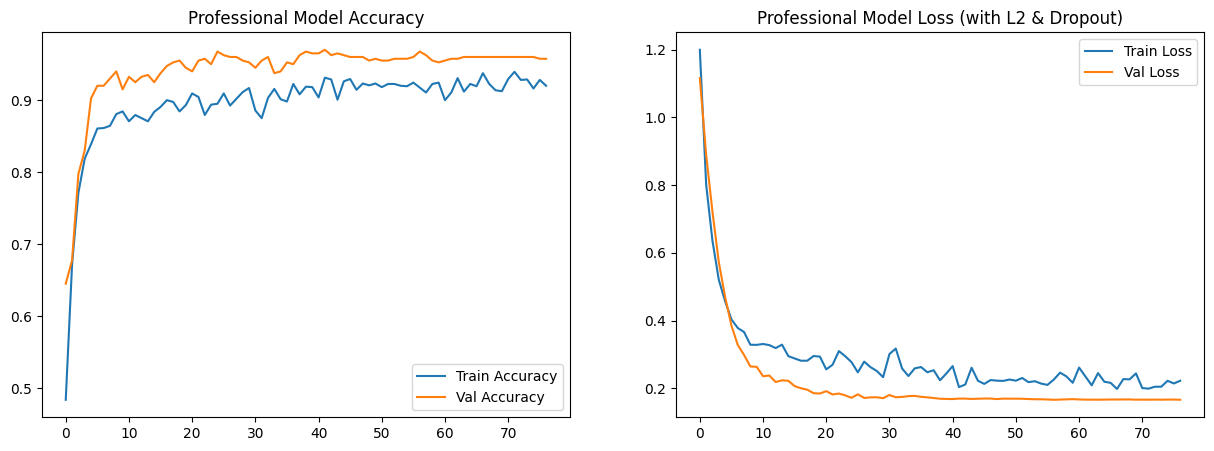

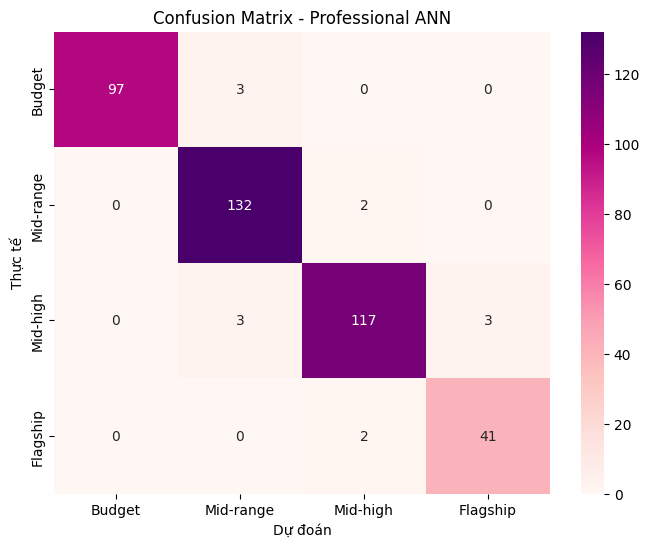


--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

      Budget       1.00      0.97      0.98       100
   Mid-range       0.96      0.99      0.97       134
    Mid-high       0.97      0.95      0.96       123
    Flagship       0.93      0.95      0.94        43

    accuracy                           0.97       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.97      0.97      0.97       400



In [61]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Dự đoán trên tập test
y_probs_p = pro_model.predict(X_test_p, verbose=0)
y_pred_p = np.argmax(y_probs_p, axis=1)

# 2. Vẽ biểu đồ Training History
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history_p.history['accuracy'], label='Train Accuracy')
plt.plot(history_p.history['val_accuracy'], label='Val Accuracy')
plt.title('Professional Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_p.history['loss'], label='Train Loss')
plt.plot(history_p.history['val_loss'], label='Val Loss')
plt.title('Professional Model Loss (with L2 & Dropout)')
plt.legend()
plt.show()

# 3. Confusion Matrix
segments = ['Budget', 'Mid-range', 'Mid-high', 'Flagship']
cm_p = confusion_matrix(y_test_p, y_pred_p)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='RdPu', xticklabels=segments, yticklabels=segments)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - Professional ANN')
plt.show()

# 4. Classification Report
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y_test_p, y_pred_p, target_names=segments))

### 📊 Đánh giá hiệu năng chi tiết (Professional Evaluation)
Chúng ta sẽ phân tích sâu các chỉ số Precision, Recall và F1-Score cho từng phân khúc, đặc biệt là Mid-high.

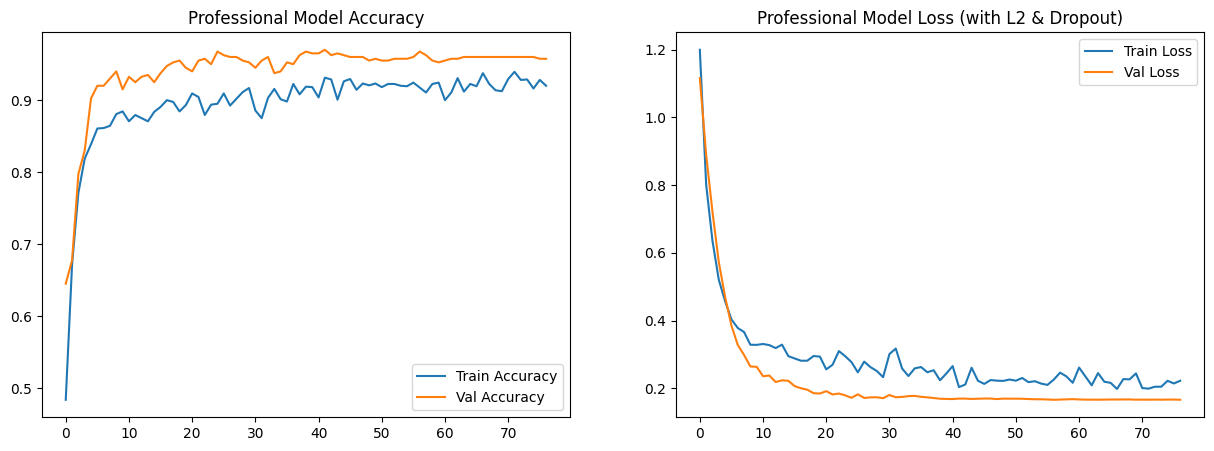

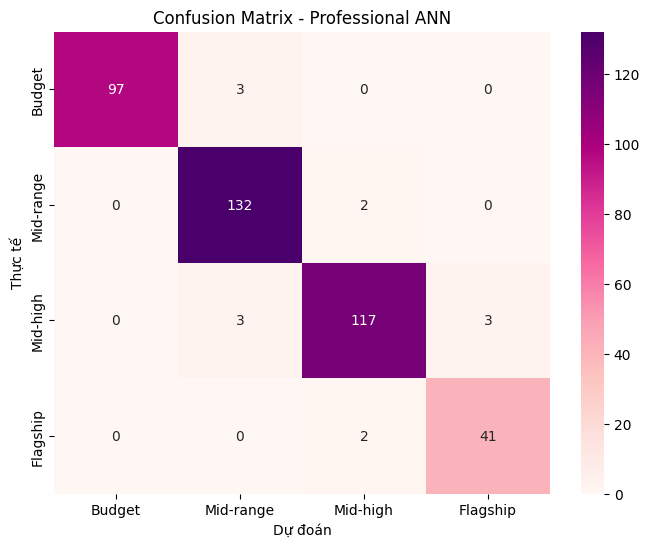


--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

      Budget       1.00      0.97      0.98       100
   Mid-range       0.96      0.99      0.97       134
    Mid-high       0.97      0.95      0.96       123
    Flagship       0.93      0.95      0.94        43

    accuracy                           0.97       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.97      0.97      0.97       400



In [60]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Dự đoán trên tập test
y_probs_p = pro_model.predict(X_test_p, verbose=0)
y_pred_p = np.argmax(y_probs_p, axis=1)

# 2. Vẽ biểu đồ Training History
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history_p.history['accuracy'], label='Train Accuracy')
plt.plot(history_p.history['val_accuracy'], label='Val Accuracy')
plt.title('Professional Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_p.history['loss'], label='Train Loss')
plt.plot(history_p.history['val_loss'], label='Val Loss')
plt.title('Professional Model Loss (with L2 & Dropout)')
plt.legend()
plt.show()

# 3. Confusion Matrix
segments = ['Budget', 'Mid-range', 'Mid-high', 'Flagship']
cm_p = confusion_matrix(y_test_p, y_pred_p)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='RdPu', xticklabels=segments, yticklabels=segments)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix - Professional ANN')
plt.show()

# 4. Classification Report
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y_test_p, y_pred_p, target_names=segments))

# Cell đã được dọn dẹp

In [78]:
# Cell đã được dọn dẹp

# Cell đã được dọn dẹp

In [79]:
# Cell đã được dọn dẹp

### 4. Evaluation and Saving
We plot the accuracy/loss and save the model file.

In [80]:
# Cell đã được dọn dẹp

In [81]:
# Cell đã được dọn dẹp

### 5. Dự đoán với dữ liệu tùy chỉnh (External Data)
Hãy thay đổi các giá trị dưới đây để kiểm tra dự đoán của mô hình.

In [82]:
# Cell đã được dọn dẹp

### Chạy thử nghiệm mô hình (Model Testing)
Sử dụng hàm `predict_phone` đã định nghĩa ở trên để kiểm tra một cấu hình điện thoại thực tế.

In [64]:
# =========================
# TEST NHIỀU PHÂN KHÚC
# =========================

test_cases = [

    # 1. SIÊU GIÁ RẺ
    ({
        'battery_power': 1200,
        'blue': 1,
        'clock_speed': 1.0,
        'dual_sim': 1,
        'fc': 1,
        'four_g': 0,
        'int_memory': 4,
        'm_dep': 0.9,
        'mobile_wt': 220,
        'n_cores': 2,
        'pc': 2,
        'px_height': 480,
        'px_width': 800,
        'ram': 512,
        'sc_h': 10,
        'sc_w': 5,
        'talk_time': 5,
        'three_g': 0,
        'touch_screen': 0,
        'wifi': 0
    }, "SIÊU GIÁ RẺ"),


    # 2. GIÁ RẺ
    ({
        'battery_power': 2500,
        'blue': 1,
        'clock_speed': 1.5,
        'dual_sim': 1,
        'fc': 5,
        'four_g': 1,
        'int_memory': 32,
        'm_dep': 0.7,
        'mobile_wt': 195,
        'n_cores': 4,
        'pc': 13,
        'px_height': 720,
        'px_width': 1600,
        'ram': 2000,
        'sc_h': 14,
        'sc_w': 6,
        'talk_time': 10,
        'three_g': 1,
        'touch_screen': 1,
        'wifi': 1
    }, "GIÁ RẺ"),


    # 3. TẦM TRUNG
    ({
        'battery_power': 5000,
        'blue': 1,
        'clock_speed': 2.2,
        'dual_sim': 1,
        'fc': 13,
        'four_g': 1,
        'int_memory': 128,
        'm_dep': 0.6,
        'mobile_wt': 190,
        'n_cores': 6,
        'pc': 50,
        'px_height': 1080,
        'px_width': 2400,
        'ram': 6000,
        'sc_h': 16,
        'sc_w': 7,
        'talk_time': 18,
        'three_g': 1,
        'touch_screen': 1,
        'wifi': 1
    }, "TẦM TRUNG"),


    # 4. CẬN CAO CẤP
    ({
        'battery_power': 5200,
        'blue': 1,
        'clock_speed': 2.8,
        'dual_sim': 1,
        'fc': 32,
        'four_g': 1,
        'int_memory': 256,
        'm_dep': 0.4,
        'mobile_wt': 185,
        'n_cores': 8,
        'pc': 108,
        'px_height': 1440,
        'px_width': 3200,
        'ram': 8000,
        'sc_h': 17,
        'sc_w': 8,
        'talk_time': 25,
        'three_g': 1,
        'touch_screen': 1,
        'wifi': 1
    }, "CẬN CAO CẤP"),


    # 5. FLAGSHIP
    ({
        'battery_power': 6000,
        'blue': 1,
        'clock_speed': 3.2,
        'dual_sim': 1,
        'fc': 50,
        'four_g': 1,
        'int_memory': 512,
        'm_dep': 0.2,
        'mobile_wt': 210,
        'n_cores': 8,
        'pc': 200,
        'px_height': 2160,
        'px_width': 3840,
        'ram': 16000,
        'sc_h': 18,
        'sc_w': 9,
        'talk_time': 35,
        'three_g': 1,
        'touch_screen': 1,
        'wifi': 1
    }, "FLAGSHIP"),


    # 6. CASE BẪY MODEL
    # RAM thấp nhưng camera mạnh
    ({
        'battery_power': 5000,
        'blue': 1,
        'clock_speed': 3.0,
        'dual_sim': 1,
        'fc': 50,
        'four_g': 1,
        'int_memory': 512,
        'm_dep': 0.2,
        'mobile_wt': 180,
        'n_cores': 8,
        'pc': 200,
        'px_height': 2160,
        'px_width': 3840,
        'ram': 1500,
        'sc_h': 18,
        'sc_w': 9,
        'talk_time': 30,
        'three_g': 1,
        'touch_screen': 1,
        'wifi': 1
    }, "CASE BẪY MODEL")


]

# =========================
# CHẠY TEST
# =========================

for phone, label in test_cases:
    predict_phone(phone, label)

--- SIÊU GIÁ RẺ ---
RAM: 512MB | Dự đoán: Giá rẻ (Budget) (100.00%)

--- GIÁ RẺ ---
RAM: 2000MB | Dự đoán: Giá rẻ (Budget) (100.00%)

--- TẦM TRUNG ---
RAM: 6000MB | Dự đoán: Tầm trung (Mid-range) (58.05%)

--- CẬN CAO CẤP ---
RAM: 8000MB | Dự đoán: Tầm trung (Mid-range) (99.18%)

--- FLAGSHIP ---
RAM: 16000MB | Dự đoán: Cao cấp (Flagship) (90.09%)

--- CASE BẪY MODEL ---
RAM: 1500MB | Dự đoán: Giá rẻ (Budget) (100.00%)

